# Import libraries

In [ ]:
# Import libraries
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from skbio.stats.composition import clr
from sklearn.covariance import GraphicalLassoCV
import seaborn as sns
import warnings

from scipy.spatial.distance import pdist, squareform
from scipy.stats import chi2
import mlflow
from scipy import stats


from matplotlib.patches import Ellipse

from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa

import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import osmnx as ox
import os
import geopandas as gpd

from matplotlib.colors import LinearSegmentedColormap


from ml.data_loading import DatabaseRSA, db_reader
from ml.models import TrainTestSplit, load_and_prep_data
from ml.pipeline import build_modelling_pipeline
from ml.features import ZeroColumnFilter, CLRFilter, MicrobiomeFeatureEngineer, KBestFeatureSelection
warnings.filterwarnings("ignore", message="invalid value encountered in subtract")

# Plotting Style

In [2]:
# =============================================================================
# Publication plotting style
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 300,
    'savefig.dpi': 600
})




In [3]:
samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
rsa = DatabaseRSA(db="../databases/malmo.db", db_table="malmo_phylum")
df_phylum = rsa.merge_data(samples.get_samples(), rsa.sql_to_clean())
df_phylum = df_phylum.drop_duplicates(subset="sample_id")
df_phylum.head()


#samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
#rsa = DatabaseRSA(db="../databases/malmo.db", db_table="malmo_species")
#df_species = rsa.merge_data(samples.get_samples(), rsa.sql_to_clean())
#df_species = df_species.drop_duplicates(subset="sample_id")
#df_species.head()


samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
rsa = DatabaseRSA(db="../databases/malmo.db", db_table="malmo_order")
df_order = rsa.merge_data(samples.get_samples(), rsa.sql_to_clean())
df_order = df_order.drop_duplicates(subset="sample_id")
df_order.head()

,sample_id,latitude,longitude,zone,Abditibacteriales,Acanthocystida,Acanthoecida,Acanthopleuribacterales,Acanthuriformes,Acarosporales,...,Xylariales,Xylonales,Zingiberales,Zoantharia,Zoopagales,Zoraptera,Zurhausenvirales,Zygentoma,Zygnematales,Zygophyllales
0,zr23059_1,55.582409,12.950183,Zone C - Limhamn,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,zr23059_2,55.579586,13.018840,Zone H - Fosie,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,zr23059_3,55.559470,13.021110,Zone H - Fosie,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,zr23059_4,55.572364,12.917626,Zone C - Limhamn,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,zr23059_5,55.559686,13.012436,Zone H - Fosie,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# RSA

In [4]:
def plot_barplot_by_zone(df: pd.DataFrame, save_path: str = "stacked_barplot.png"):
    """
    Plot stacked barplot with for each zone.
    """
    # Filter dataframe
    df = df.drop(["sample_id", "latitude", "longitude"], axis=1)
    # Convert everything except zone to float
    df = df.astype({col: "float" for col in df.columns if col != "zone"})
    zone_df = df.groupby(by="zone").mean()

    zone_df = zone_df.loc[:, (zone_df >= 0.005).any(axis=0)]

    # Plot stacked bar plot
    # set the figure size
    plt.figure(figsize=(14, 14))
    zone_df.iloc[:, :10].plot(kind="bar", stacked=True, figsize=(14, 8))
    plt.title("RSA Values by Zone and Phylum")
    plt.xlabel("Zone")
    plt.ylabel("RSA Value")
    plt.legend(title="Phylum", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return zone_df

<Figure size 4200x4200 with 0 Axes>

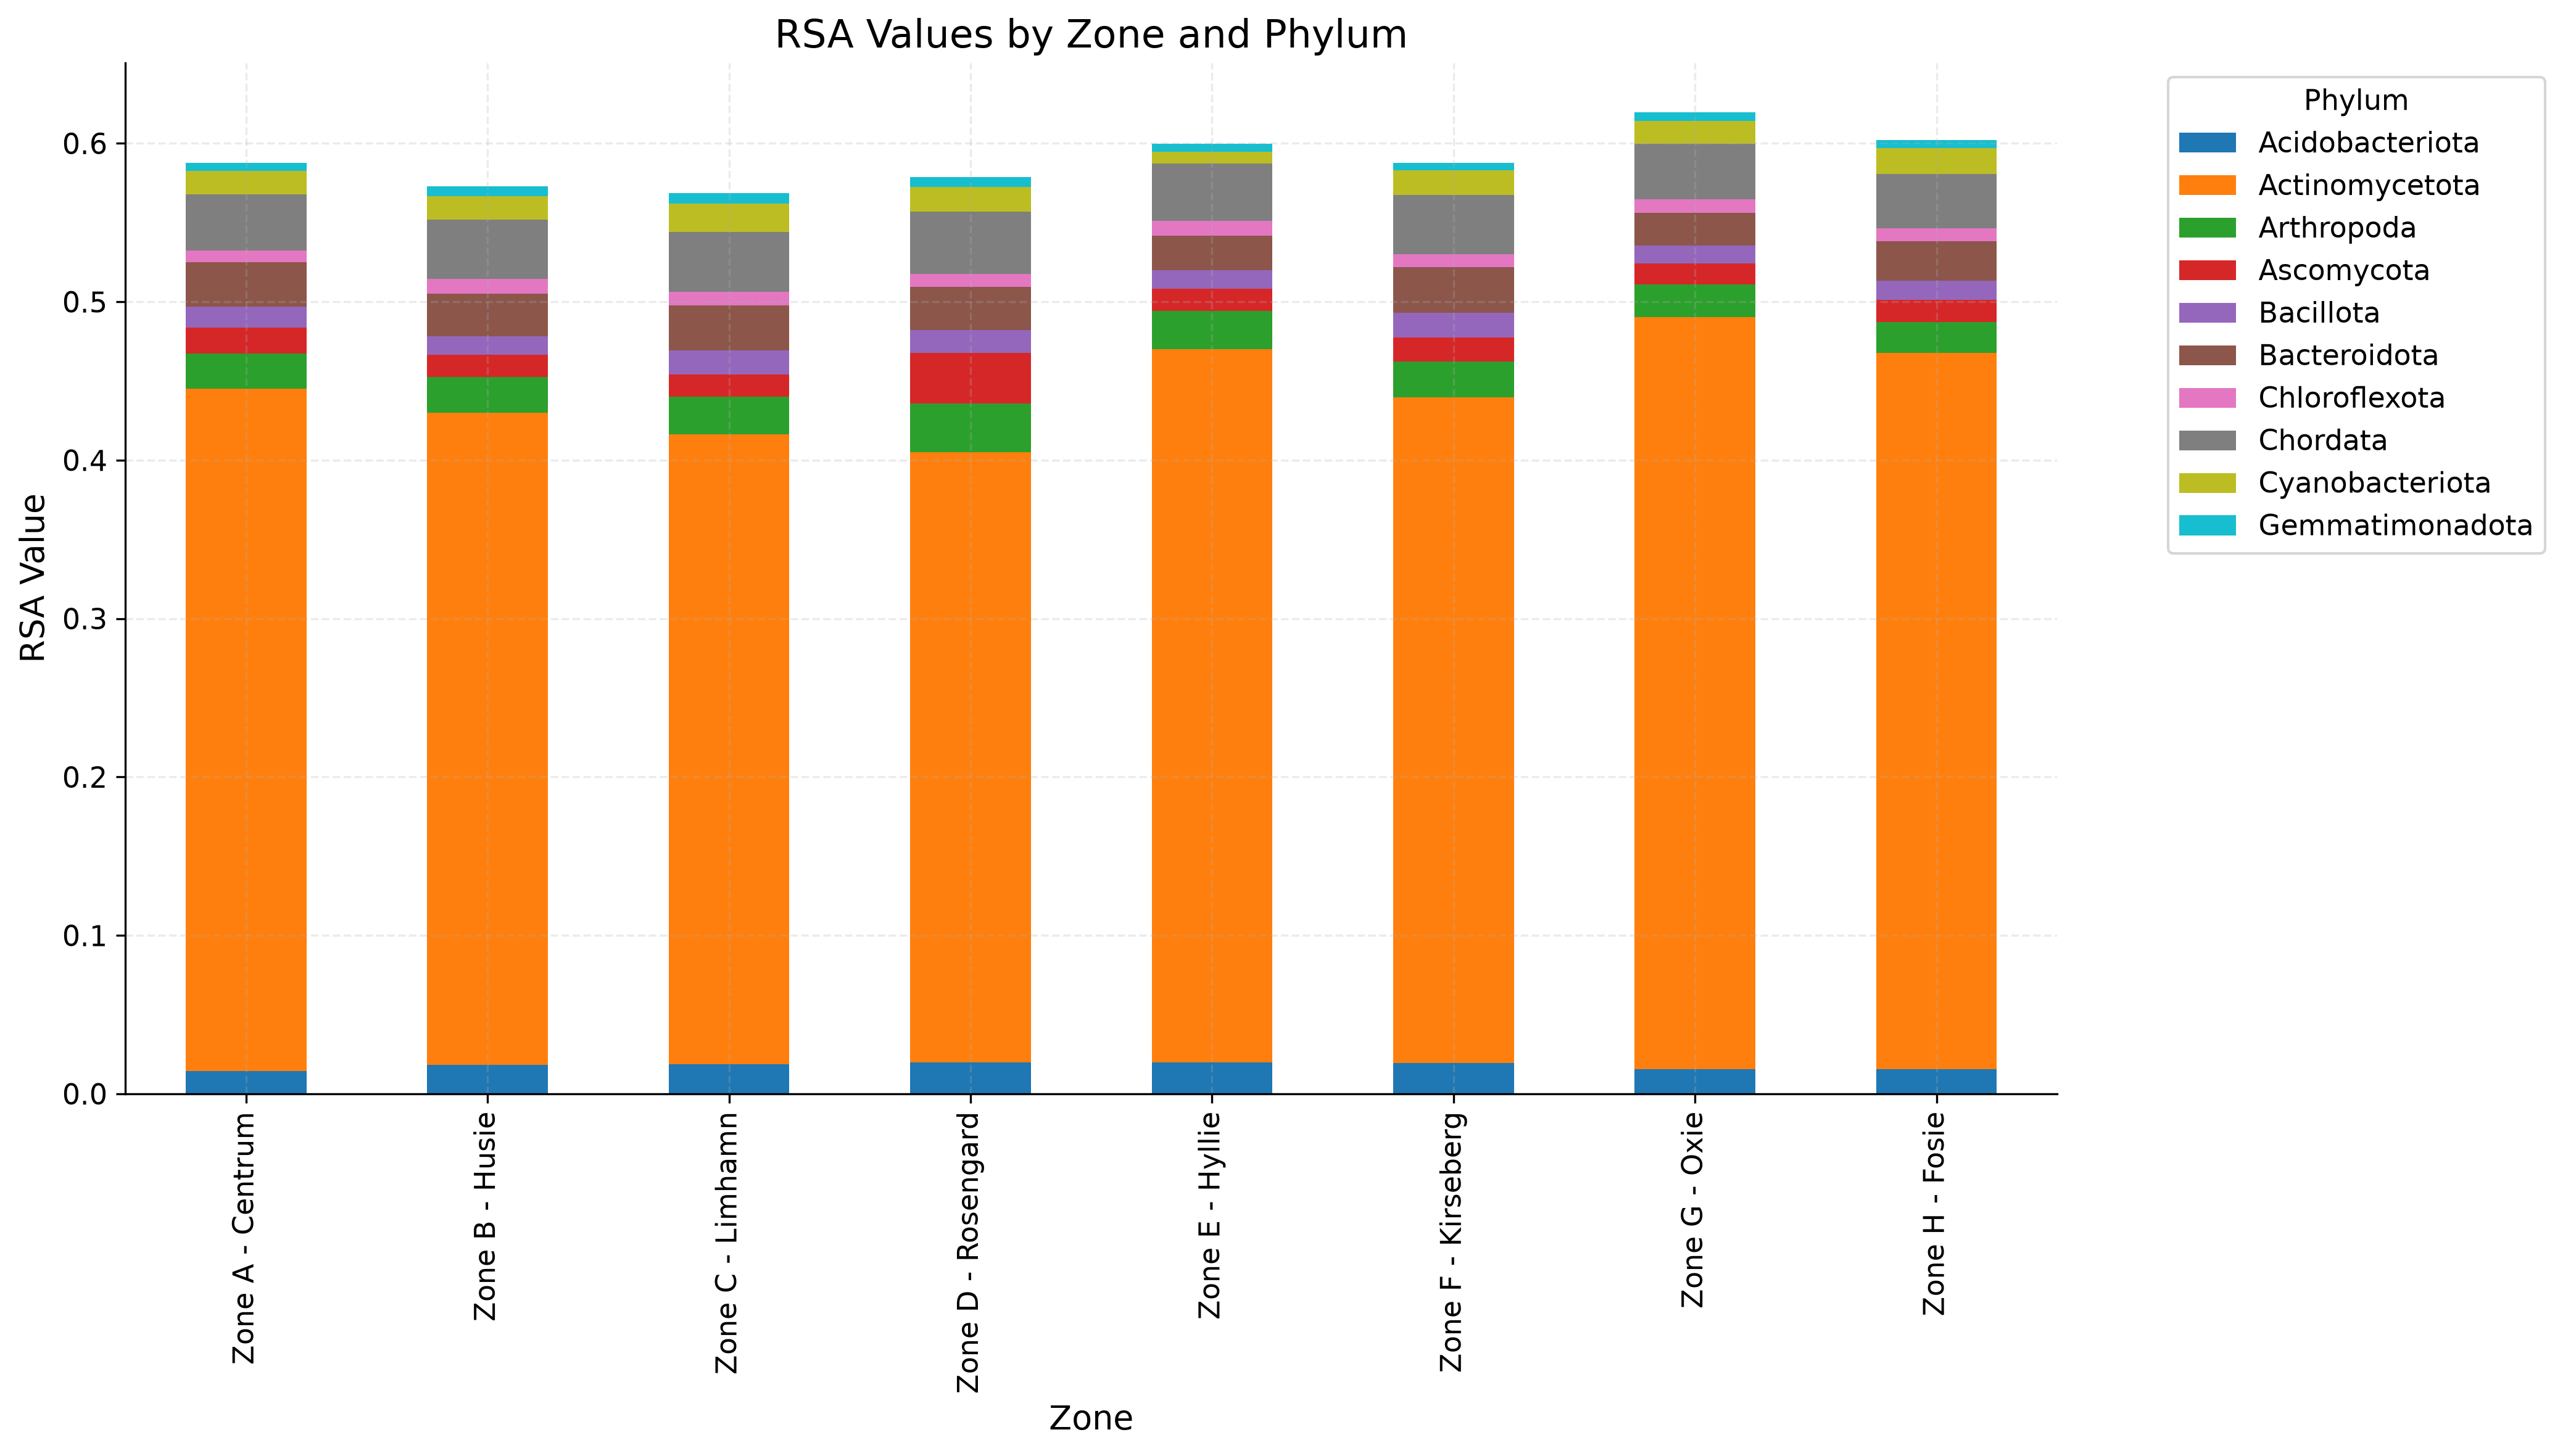

In [5]:
zone_df = plot_barplot_by_zone(df_phylum)

In [6]:
df_phylum['Pseudomonadota'].max()

np.float64(0.45976)

In [7]:
zone_df

,Acidobacteriota,Actinomycetota,Arthropoda,Ascomycota,Bacillota,Bacteroidota,Chloroflexota,Chordata,Cyanobacteriota,Gemmatimonadota,Methanobacteriota,Myxococcota,Planctomycetota,Pseudomonadota,Streptophyta
zone,,,,,,,,,,,,,,,
Zone A - Centrum,0.014383,0.430872,0.022237,0.016355,0.012964,0.028108,0.007529,0.035383,0.014769,0.004937,0.005315,0.012769,0.012822,0.321733,0.015209
Zone B - Husie,0.018346,0.411445,0.022592,0.013982,0.011850,0.026971,0.009170,0.037533,0.014697,0.006281,0.005939,0.013505,0.015745,0.328216,0.014804
Zone C - Limhamn,0.018547,0.397643,0.023751,0.013975,0.015535,0.028244,0.008685,0.037817,0.017697,0.006541,0.005865,0.012764,0.014447,0.335413,0.015149
Zone D - Rosengard,0.019799,0.385381,0.030572,0.032008,0.014382,0.027083,0.008407,0.039157,0.015774,0.005964,0.006011,0.011532,0.015264,0.324908,0.016232
Zone E - Hyllie,0.019980,0.449890,0.024309,0.014018,0.011666,0.021943,0.009322,0.036131,0.007523,0.004874,0.006030,0.012830,0.015248,0.305578,0.014484
Zone F - Kirseberg,0.019448,0.420290,0.022540,0.015267,0.015430,0.028733,0.008255,0.037357,0.015589,0.004881,0.005656,0.012051,0.016020,0.314790,0.015967
Zone G - Oxie,0.015580,0.474877,0.020560,0.013097,0.011170,0.020670,0.008787,0.035040,0.014390,0.005597,0.005977,0.013873,0.014063,0.294860,0.013740
Zone H - Fosie,0.015439,0.452116,0.019563,0.014135,0.012146,0.024879,0.008047,0.034214,0.016390,0.004978,0.005760,0.010339,0.012863,0.312811,0.013839


In [8]:
data = df_phylum["Pseudomonadota"].dropna()
print(data.describe())
print(f"Percentiles: 5%={data.quantile(0.05)}, 95%={data.quantile(0.95)}")

count    262.000000
mean       0.319719
std        0.041188
min        0.200330
25%        0.290822
50%        0.319260
75%        0.347220
max        0.459760
Name: Pseudomonadota, dtype: float64
Percentiles: 5%=0.2564045, 95%=0.39054199999999994


Fetching Malmö boundary from OpenStreetMap...
Boundary loaded: Malmö
  Loaded 185 features for tags {'natural': 'water', 'waterway': ['river', 'canal']}
  Loaded 1558 features for tags {'leisure': 'park', 'landuse': 'grass', 'natural': 'wood'}
  Loaded 13354 road segments


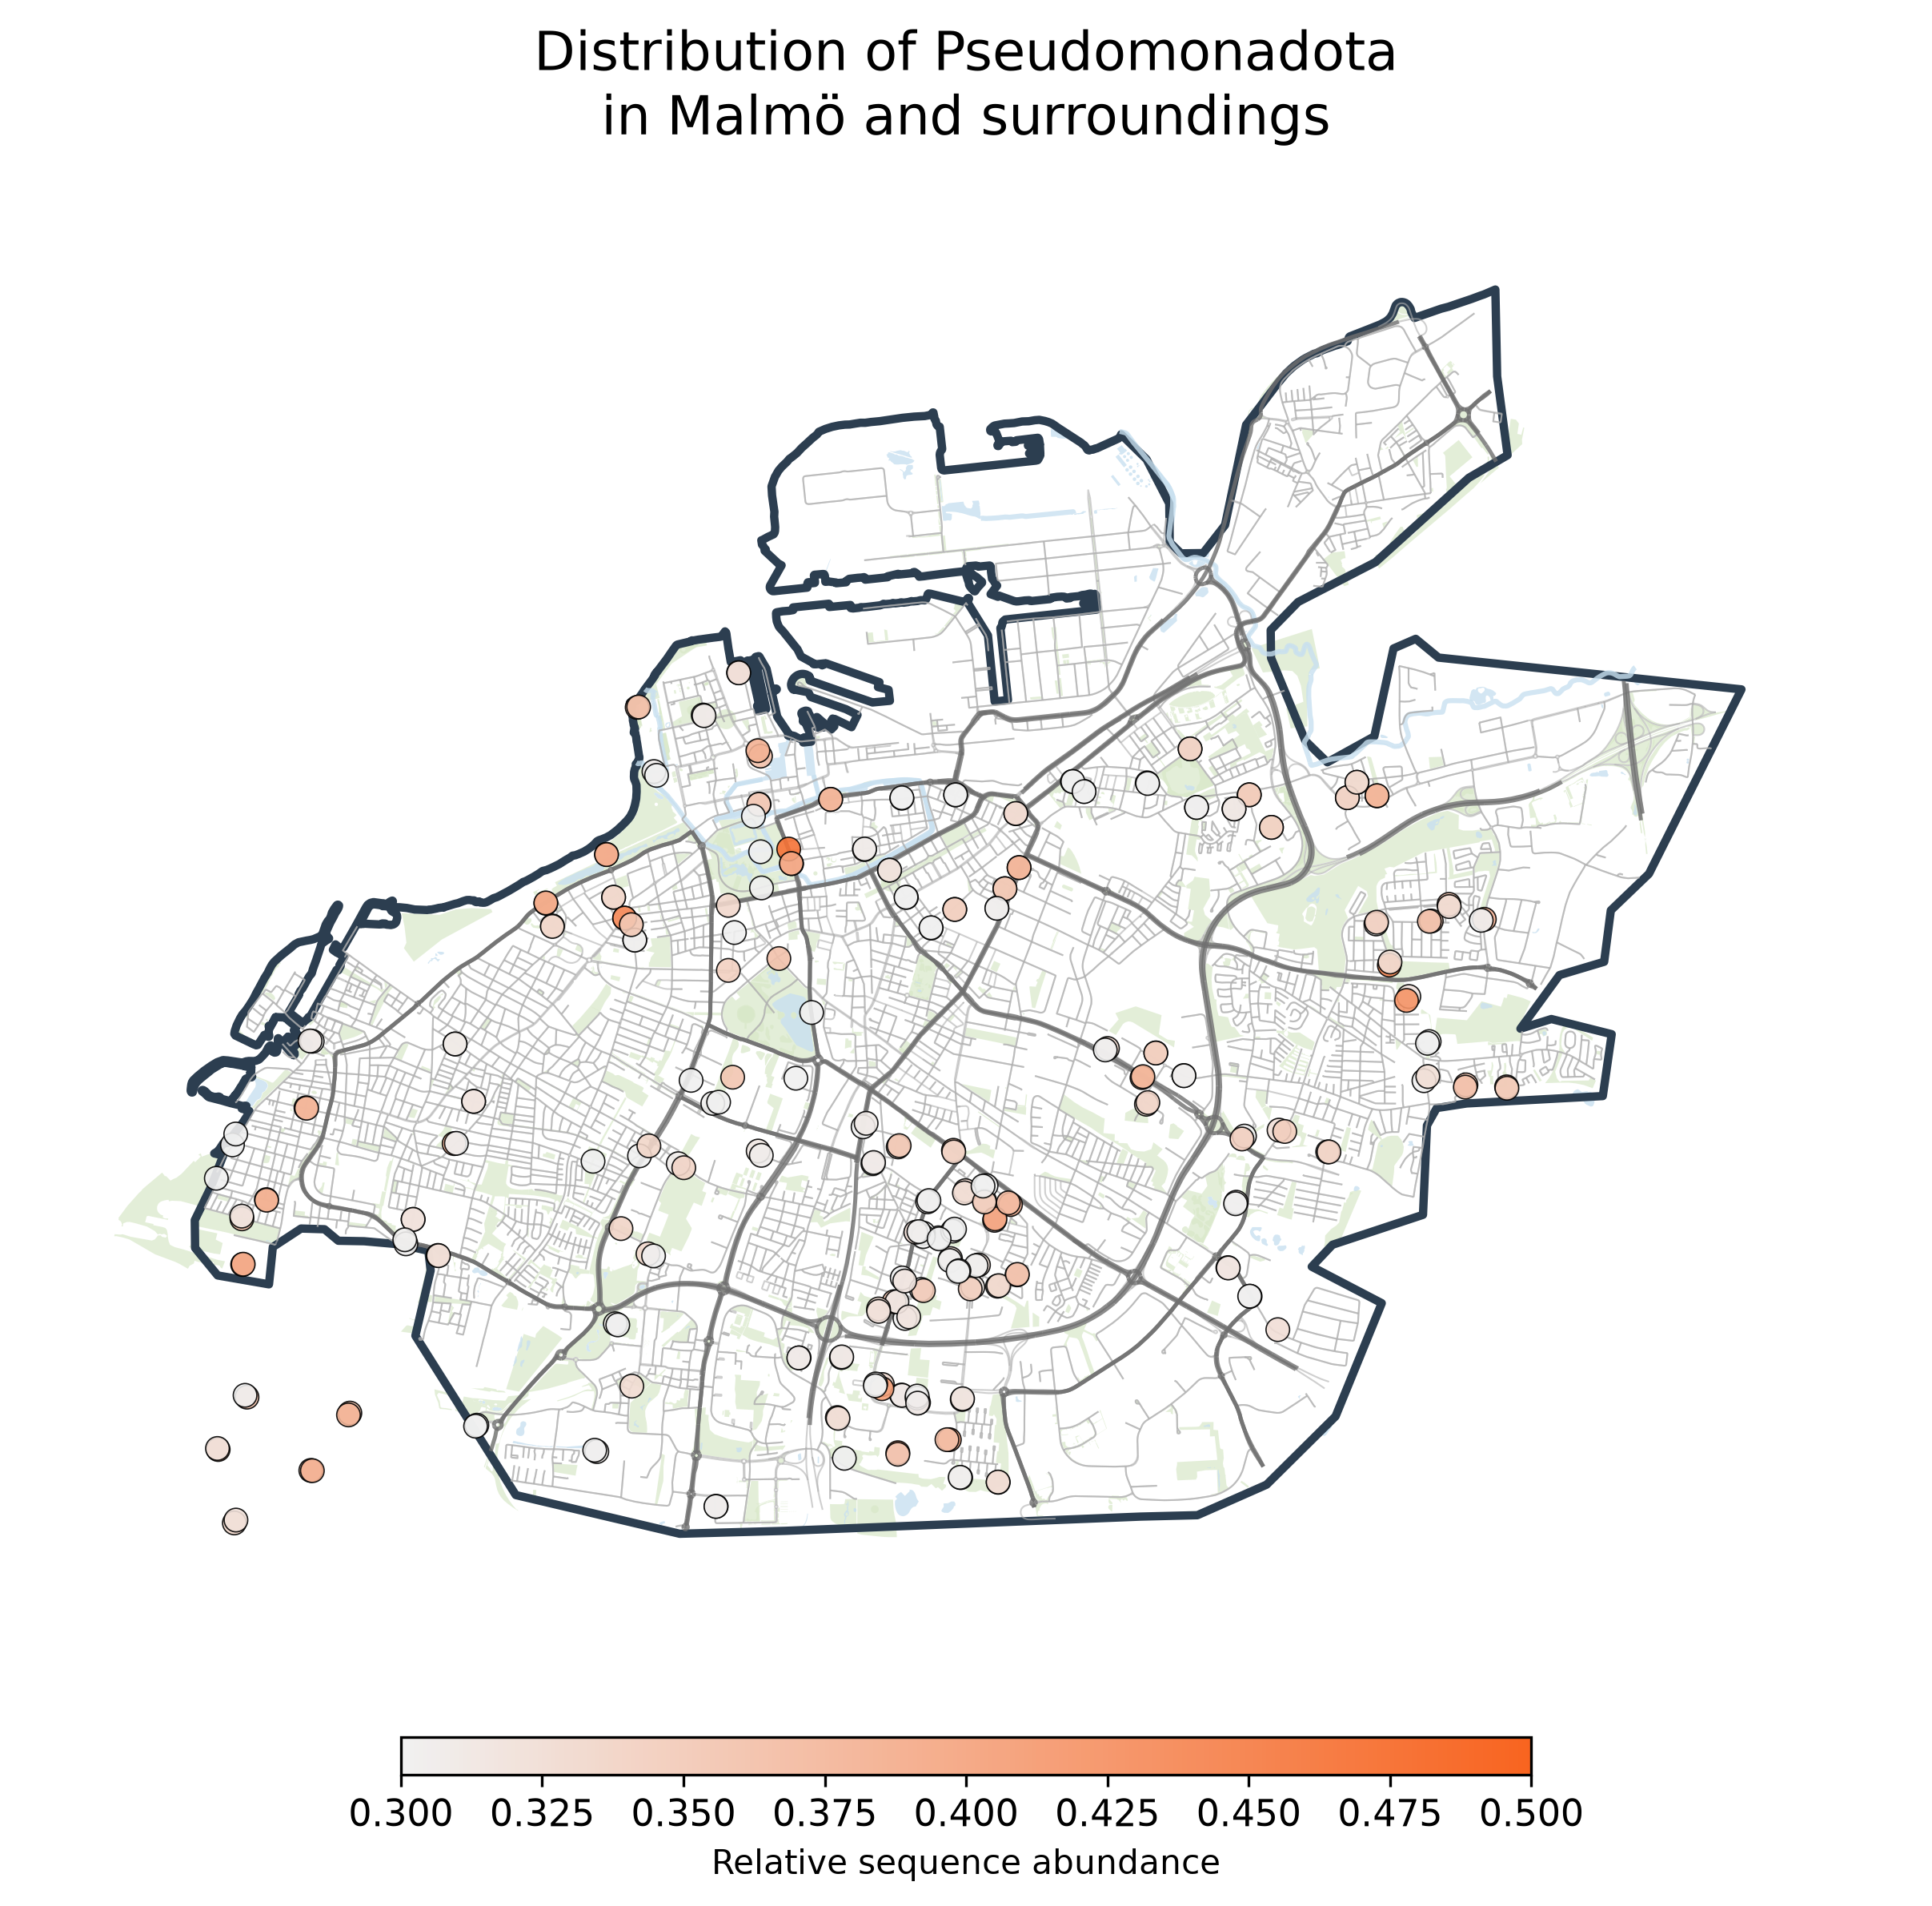

Map saved as PNG and PDF (compact, with horizontal colorbar).


In [74]:
# Choose which order to plot
target_order = "Pseudomonadota"

# =============================================================================
# 1. LOAD MALMÖ BOUNDARY
# =============================================================================
def load_malmo_boundary():
    print("Fetching Malmö boundary from OpenStreetMap...")
    admin = ox.geocode_to_gdf("Malmö, Sweden")
    print(f"Boundary loaded: {admin['name'].iloc[0]}")
    return admin

boundary = load_malmo_boundary()

# =============================================================================
# 2. LOAD ADDITIONAL VECTOR LAYERS (water, parks, roads)
# =============================================================================
def load_osm_features(place, tags):
    try:
        gdf = ox.features_from_place(place, tags=tags)
        print(f"  Loaded {len(gdf)} features for tags {tags}")
        return gdf
    except Exception as e:
        print(f"  Skipping {tags}: {e}")
        return gpd.GeoDataFrame()

place_name = "Malmö, Sweden"

print("Downloading additional OSM layers...")
water = load_osm_features(place_name, {"natural": "water", "waterway": ["river", "canal"]})
parks = load_osm_features(place_name, {"leisure": "park", "landuse": "grass", "natural": "wood"})

print("Downloading street network...")
try:
    graph = ox.graph_from_place(place_name, network_type="drive")
    edges = ox.graph_to_gdfs(graph, nodes=False, edges=True)
    print(f"  Loaded {len(edges)} road segments")
except Exception as e:
    print(f"  Could not load roads: {e}")
    edges = gpd.GeoDataFrame()

# =============================================================================
# 3. PREPARE YOUR DATA POINTS
# =============================================================================
df_plot = df_phylum[df_phylum[target_order].notna()].copy()
gdf_points = gpd.GeoDataFrame(
    df_plot,
    geometry=gpd.points_from_xy(df_plot.longitude, df_plot.latitude),
    crs="EPSG:4326"
)

# Reproject everything to SWEREF99 TM (EPSG:3006)
target_crs = "EPSG:3006"
boundary = boundary.to_crs(target_crs)
if not water.empty:
    water = water.to_crs(target_crs)
if not parks.empty:
    parks = parks.to_crs(target_crs)
if not edges.empty:
    edges = edges.to_crs(target_crs)
gdf_points = gdf_points.to_crs(target_crs)

# =============================================================================
# 4. CREATE THE STATIC MAP (compact layout)
# =============================================================================
# --- Reduce figure size to be more compact (10x10) ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- Set background colour ---
ax.set_facecolor("#f5f5f0")

# --- Parks (soft green) ---
if not parks.empty:
    parks.plot(ax=ax, color="#d8e8c8", edgecolor="none", alpha=0.7)

# --- Water (light blue) ---
if not water.empty:
    water.plot(ax=ax, color="#c8e0f0", edgecolor="none", alpha=0.8)

# --- Roads (thin grey lines) ---
if not edges.empty:
    major = edges[edges["highway"].isin(["motorway", "trunk", "primary", "secondary"])]
    minor = edges[~edges["highway"].isin(["motorway", "trunk", "primary", "secondary"])]
    if not minor.empty:
        minor.plot(ax=ax, color="#b0b0b0", linewidth=0.5, alpha=0.6)
    if not major.empty:
        major.plot(ax=ax, color="#707070", linewidth=1.2, alpha=0.8)

# --- Malmö boundary outline ---
boundary.plot(ax=ax, facecolor="none", edgecolor="#2c3e50", linewidth=2.5)

# --- Your data points (gradient circles) ---
# Custom colormap (light grey to red)
cmap = LinearSegmentedColormap.from_list("abundance", ["#f0f0f0", "#F85307"], N=256)

sc = ax.scatter(
    gdf_points.geometry.x,
    gdf_points.geometry.y,
    s=50,
    c=gdf_points[target_order],
    cmap=cmap,
    vmin=0.3,
    vmax=0.5,
    alpha=0.9,
    edgecolors="black",
    linewidth=0.4,
    zorder=10
)

# --- Set view limits with a SMALLER margin to reduce whitespace ---
minx, miny, maxx, maxy = boundary.total_bounds
margin = 1500   # meters (was 3000, now tighter)
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

# --- Colorbar: smaller, horizontal, with label below ---
# Use horizontal orientation so the label appears naturally below
cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation='horizontal',   # horizontal bar
    shrink=0.6,                # smaller width (adjust to taste)
    pad=0.02,                  # space between map and colorbar
    aspect=30,
    fraction=0.05                  # thickness (lower = thinner)
)
# Set the label (it will appear below the colorbar automatically)
cbar.set_label('Relative sequence abundance', fontsize=10)

# --- (Optional) Customise tick values if you want ---
# For example, set ticks at specific values:
# cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
# cbar.set_ticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])

# --- Clean up axes ---
ax.set_aspect("equal")
ax.axis("off")   # removes ticks and frame

plt.title(f"Distribution of {target_order}\nin Malmö and surroundings", fontsize=16, y=0.98)

# --- Manual adjustment of figure margins to remove all whitespace ---
# left, bottom, right, top (in figure coordinates, 0 to 1)
plt.subplots_adjust(
    left=0.01,   # almost no left margin
    right=0.99,  # almost no right margin
    bottom=0.01, # almost no bottom margin
    top=0.99     # almost no top margin
)

# --- Use tight_layout with reduced padding to minimise whitespace ---
plt.tight_layout(pad=0.5)   # smaller padding around the figure

# =============================================================================
# 5. SAVE AS HIGH-RES PNG AND VECTOR PDF
# =============================================================================
plt.savefig(f"/home/chandru/binp51/report/figures/malmo_{target_order}_static_compact.png", dpi=300, bbox_inches="tight")
plt.show()

print("Map saved as PNG and PDF (compact, with horizontal colorbar).")

In [ ]:
zero_filter = ZeroColumnFilter()
X_filter = zero_filter.fit_transform(X)
clr_filter = CLRFilter()
X_clr = clr_filter.transform(X_filter)
X_clr

# Figure: Baseline Estimation (Machine Learning model)

In [70]:
def download_stage1_results():
    client = mlflow.tracking.MlflowClient()

    # 1. Get all experiment IDs
    experiments = client.search_experiments()
    experiment_ids = [exp.experiment_id for exp in experiments]

    if not experiment_ids:
        print("No experiments found.")
        return pd.DataFrame()

    # 2. Search for runs with the stage tag across all experiments
    runs = client.search_runs(
        experiment_ids=experiment_ids,  # <- now a list
        filter_string="params.cv_strategy = 'group_kfold'"
    )

    # 3. Extract data
    data = []
    for run in runs:
        row = {
            #"run_id": run.info.run_id,
            #"experiment_id": run.info.experiment_id,
            "taxonomy_level": run.data.tags.get("taxonomy_level", ""),
            "model_type": run.data.tags.get("model_type", ""),
            "cv_strategy": run.data.params.get("cv_strategy",""),
            "mean_error_km": run.data.metrics.get("cv_mean_error_km", None),
            "median_error_km": run.data.metrics.get("cv_median_error_km", None),
            "max_error_km": run.data.metrics.get("cv_max_error_km", None),
            "experiment_stage": run.data.tags.get('mlflow.runName',None),
            "features": run.data.tags.get("fe_variant"),
            "community": run.data.params.get("fe_use_community"),
            "global_graph": run.data.params.get("fe_use_global_graph"),
            "spectral": run.data.params.get("fe_use_spectral")
            
        }
        data.append(row)

    df = pd.DataFrame(data)

    return df

# Usage
os.chdir("/home/chandru/binp51/src/ml/")
mlflow_df = download_stage1_results()

In [71]:
mlflow_df['experiment_stage']=mlflow_df['experiment_stage'].apply(lambda x: x.split("_")[0])
mlflow_df.loc[0, "features"] = "CLR_Spectral_Global_Community"
mlflow_df.head()

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
0,order,ExtraTreesRegressor,group_kfold,3.876966,3.881513,5.555052,stage3,CLR_Spectral_Global_Community,True,True,True
1,order,ExtraTreesRegressor,group_kfold,3.886982,3.933548,5.848666,stage2,CLR_Spectral_Global_Community,None,None,None
2,order,ExtraTreesRegressor,group_kfold,3.950691,4.036995,5.898409,stage2,CLR_Global_Community,None,None,None
3,order,ExtraTreesRegressor,group_kfold,3.927244,3.966572,5.958524,stage2,CLR_Spectral_Community,None,None,None
4,order,ExtraTreesRegressor,group_kfold,3.918483,4.064740,5.871850,stage2,CLR_Spectral_Global,None,None,None


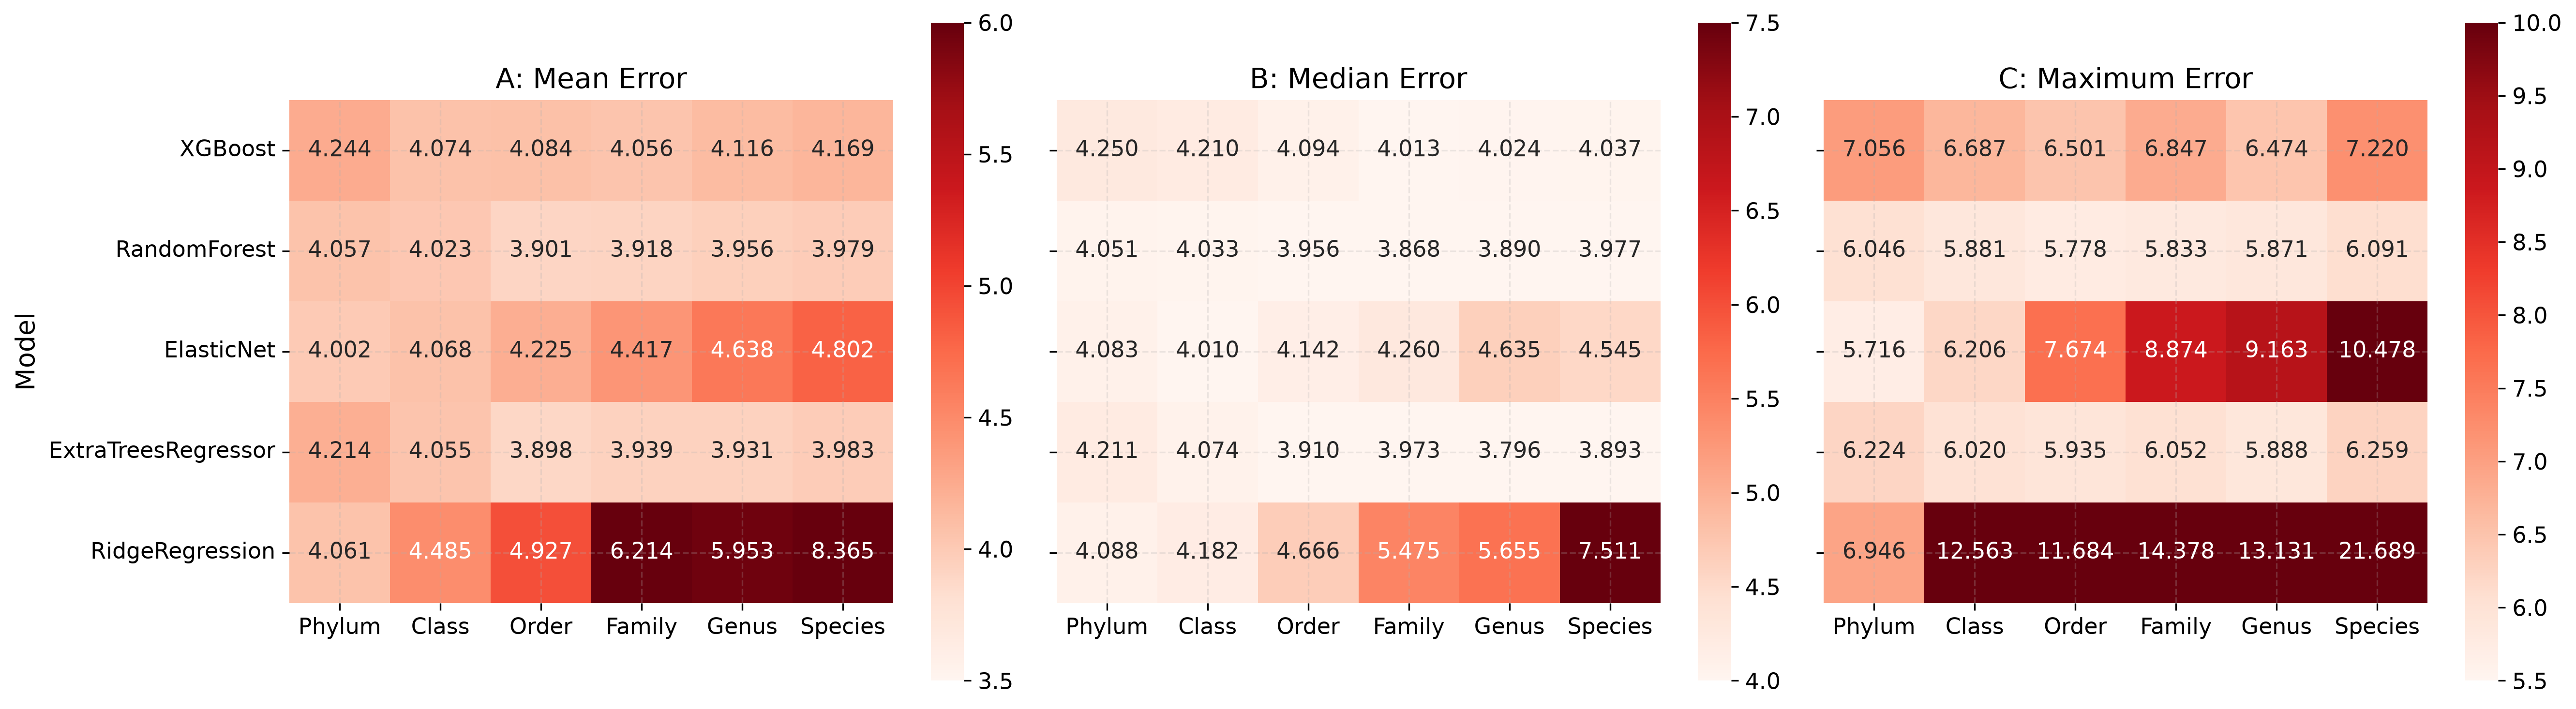

In [ ]:
# 1. Prepare the data: aggregate duplicate runs

stage_1_df = mlflow_df[mlflow_df['experiment_stage']=='stage1']
df_agg = stage_1_df.groupby(['model_type', 'taxonomy_level']).agg({
    'mean_error_km': 'min',
    'median_error_km': 'min',
    'max_error_km': 'min'
}).reset_index()

# 2. Define the desired order of taxa and models
taxonomy_order = ["Phylum", "Class", "Order", "Family", "Genus", "Species"]
# Map the actual column values to title case (if needed)
df_agg['taxonomy'] = df_agg['taxonomy_level'].str.title()

# Model order (from your original list)
model_order = ["XGBoost", "RandomForest", "ElasticNet", "ExtraTreesRegressor", "RidgeRegression"]

# 3. Pivot to matrices (models x taxa)
pivot_mean = df_agg.pivot(index='model_type', columns='taxonomy', values='mean_error_km')
pivot_median = df_agg.pivot(index='model_type', columns='taxonomy', values='median_error_km')
pivot_max = df_agg.pivot(index='model_type', columns='taxonomy', values='max_error_km')

# Reindex to enforce order
pivot_mean = pivot_mean.reindex(index=model_order, columns=taxonomy_order)
pivot_median = pivot_median.reindex(index=model_order, columns=taxonomy_order)
pivot_max = pivot_max.reindex(index=model_order, columns=taxonomy_order)

# 4. Create the three‑panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cmap = "Reds"


# Mean error
sns.heatmap(pivot_mean, ax=axes[0], cmap=cmap, vmin=3.5, vmax=6,
            annot=True, fmt=".3f", cbar=True, square=True,
            cbar_kws={"shrink": 0.8})
axes[0].set_title("A: Mean Error", fontsize=14)
axes[0].set_ylabel("Model")
axes[0].set_xlabel("")
axes[0].set_yticklabels(model_order, rotation=00)

# Median error
sns.heatmap(pivot_median, ax=axes[1], cmap=cmap, vmin=4, vmax=7.5,
            annot=True, fmt=".3f", cbar=True, square=True,
            cbar_kws={"shrink": 0.8})
axes[1].set_title("B: Median Error", fontsize=14)
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].set_yticklabels([])

# Maximum error
sns.heatmap(pivot_max, ax=axes[2], cmap=cmap, vmin=5.5, vmax=10,
            annot=True, fmt=".3f", cbar=True, square=True,
            cbar_kws={"shrink": 0.8})
axes[2].set_title("C: Maximum Error", fontsize=14)
axes[2].set_ylabel("")
axes[2].set_xlabel("")
axes[2].set_yticklabels([])

plt.tight_layout()
plt.savefig("/home/chandru/binp51/report/figures/three_panel_error_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Table: Stage 2 Feature engineering results

In [75]:
stage_2_df = mlflow_df[mlflow_df['experiment_stage']=="stage2"]
stage_2_df

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
1,order,ExtraTreesRegressor,group_kfold,3.886982,3.933548,5.848666,stage2,CLR_Spectral_Global_Community,None,None,None
2,order,ExtraTreesRegressor,group_kfold,3.950691,4.036995,5.898409,stage2,CLR_Global_Community,None,None,None
3,order,ExtraTreesRegressor,group_kfold,3.927244,3.966572,5.958524,stage2,CLR_Spectral_Community,None,None,None
4,order,ExtraTreesRegressor,group_kfold,3.918483,4.064740,5.871850,stage2,CLR_Spectral_Global,None,None,None
5,order,ExtraTreesRegressor,group_kfold,3.941322,4.001945,5.998363,stage2,CLR_Community,None,None,None
6,order,ExtraTreesRegressor,group_kfold,3.917958,4.044363,5.915181,stage2,CLR_Global,None,None,None
7,order,ExtraTreesRegressor,group_kfold,3.950391,4.003292,6.028800,stage2,CLR_Spectral,None,None,None


# Table: Stage 3 Hyperparameter Tuning Results

In [76]:
mlflow_df[(mlflow_df['model_type'] == 'ExtraTreesRegressor') & (mlflow_df['taxonomy_level'] == 'order')]

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
0,order,ExtraTreesRegressor,group_kfold,3.876966,3.881513,5.555052,stage3,CLR_Spectral_Global_Community,True,True,True
1,order,ExtraTreesRegressor,group_kfold,3.886982,3.933548,5.848666,stage2,CLR_Spectral_Global_Community,None,None,None
2,order,ExtraTreesRegressor,group_kfold,3.950691,4.036995,5.898409,stage2,CLR_Global_Community,None,None,None
3,order,ExtraTreesRegressor,group_kfold,3.927244,3.966572,5.958524,stage2,CLR_Spectral_Community,None,None,None
4,order,ExtraTreesRegressor,group_kfold,3.918483,4.064740,5.871850,stage2,CLR_Spectral_Global,None,None,None
5,order,ExtraTreesRegressor,group_kfold,3.941322,4.001945,5.998363,stage2,CLR_Community,None,None,None
6,order,ExtraTreesRegressor,group_kfold,3.917958,4.044363,5.915181,stage2,CLR_Global,None,None,None
7,order,ExtraTreesRegressor,group_kfold,3.950391,4.003292,6.028800,stage2,CLR_Spectral,None,None,None
11,order,ExtraTreesRegressor,group_kfold,3.897694,3.910024,5.934770,stage1,None,None,None,None


# Table: Wilcoxon statistic on the validation dataset for all three experiment stages

In [65]:
# Fold errors from each stage (same order: folds 1-7)
baseline = [2.74, 3.15, 6.00, 5.20, 2.98, 4.43, 2.79]
fe_untuned = [2.72, 3.16, 6.07, 5.27, 2.82, 4.40, 2.78]
fe_tuned = [2.63, 3.15, 6.01, 5.22, 2.88, 4.50, 2.74]

def compare_stages(name_a, folds_a, name_b, folds_b):
    """Run Wilcoxon signed-rank test comparing two stages."""
    diff = np.array(folds_a) - np.array(folds_b)
    mean_diff = np.mean(diff)
    
    print(f"\n{'='*50}")
    print(f"Comparison: {name_a} vs {name_b}")
    print(f"{'='*50}")
    print(f"Mean {name_a}: {np.mean(folds_a):.4f} km")
    print(f"Mean {name_b}: {np.mean(folds_b):.4f} km")
    print(f"Average improvement: {mean_diff:.4f} km")
    
    # Wilcoxon test: alternative='greater' means folds_a > folds_b (i.e., B is better)
    stat, p_value = stats.wilcoxon(folds_a, folds_b, alternative='greater')
    print(f"Wilcoxon statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"✅ {name_b} is SIGNIFICANTLY better than {name_a} (p < 0.05)")
    else:
        print(f"⚠️ Not significant (p ≥ 0.05)")
    return p_value

# Run all three comparisons
print("WILCOXON SIGNED-RANK TEST RESULTS")
print("==================================")

p1 = compare_stages("Baseline", baseline, "Untuned FE", fe_untuned)
p2 = compare_stages("Baseline", baseline, "Tuned FE", fe_tuned)
p3 = compare_stages("Untuned FE", fe_untuned, "Tuned FE", fe_tuned)

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Baseline vs Untuned FE:  p = {p1:.4f}")
print(f"Baseline vs Tuned FE:    p = {p2:.4f}")
print(f"Untuned FE vs Tuned FE:  p = {p3:.4f}")

WILCOXON SIGNED-RANK TEST RESULTS

Comparison: Baseline vs Untuned FE
Mean Baseline: 3.8986 km
Mean Untuned FE: 3.8886 km
Average improvement: 0.0100 km
Wilcoxon statistic: 15.5000
P-value: 0.4219
⚠️ Not significant (p ≥ 0.05)

Comparison: Baseline vs Tuned FE
Mean Baseline: 3.8986 km
Mean Tuned FE: 3.8757 km
Average improvement: 0.0229 km
Wilcoxon statistic: 14.0000
P-value: 0.2812
⚠️ Not significant (p ≥ 0.05)

Comparison: Untuned FE vs Tuned FE
Mean Untuned FE: 3.8886 km
Mean Tuned FE: 3.8757 km
Average improvement: 0.0129 km
Wilcoxon statistic: 17.0000
P-value: 0.3438
⚠️ Not significant (p ≥ 0.05)

SUMMARY
Baseline vs Untuned FE:  p = 0.4219
Baseline vs Tuned FE:    p = 0.2812
Untuned FE vs Tuned FE:  p = 0.3438


# Table: Wilcoxon test for tuned vs baseline significance test across 10 different random states (1..11)

In [77]:
# ---- Extract paired errors for each metric ----
baseline_mean = [3.0446, 3.2923, 3.2740, 3.3262, 2.8403, 3.0371, 3.1210, 3.1017, 2.9343, 2.9769]
tuned_mean   = [2.5136, 2.8864, 2.7172, 2.8070, 2.5002, 2.6780, 2.5005, 2.7267, 2.6867, 2.5276]

baseline_median = [3.0768, 3.2217, 2.7673, 3.2775, 2.6824, 2.8391, 2.8700, 2.7698, 2.7294, 2.9183]
tuned_median   = [2.2558, 2.6627, 2.3252, 2.6627, 2.2558, 2.3998, 2.3486, 2.4997, 2.3893, 2.4469]

baseline_max = [6.8234, 7.0483, 6.8351, 7.5727, 8.0078, 6.4512, 7.1947, 7.0423, 7.3918, 7.5088]
tuned_max   = [5.4375, 6.7045, 6.2889, 6.4310, 6.4310, 6.0002, 6.0002, 6.4310, 6.4310, 6.0002]

# ---- Run Wilcoxon tests (alternative='greater' means tuned is lower) ----
w_mean, p_mean = stats.wilcoxon(baseline_mean, tuned_mean, alternative='greater')
w_median, p_median = stats.wilcoxon(baseline_median, tuned_median, alternative='greater')
w_max, p_max = stats.wilcoxon(baseline_max, tuned_max, alternative='greater')

# ---- Apply Bonferroni correction ----
alpha = 0.05
n_tests = 3
bonferroni_alpha = alpha / n_tests

print("=" * 60)
print("WILCOXON SIGNED‑RANK TESTS (Baseline vs Tuned FE)")
print("=" * 60)
print(f"Metric     | Statistic | P‑value | Significant (p < {bonferroni_alpha:.4f})?")
print("-" * 60)
print(f"Mean Error | {w_mean:.4f}    | {p_mean:.4f}  | {'✅ YES' if p_mean < bonferroni_alpha else '❌ NO'}")
print(f"Median Error| {w_median:.4f}    | {p_median:.4f}  | {'✅ YES' if p_median < bonferroni_alpha else '❌ NO'}")
print(f"Max Error  | {w_max:.4f}    | {p_max:.4f}  | {'✅ YES' if p_max < bonferroni_alpha else '❌ NO'}")
print("=" * 60)

# Summary for paper
print("\n📝 How to report this in your paper:")
print("-" * 60)
print(f"Mean improvement:   {np.mean(baseline_mean) - np.mean(tuned_mean):.4f} km (p = {p_mean:.4f})")
print(f"Median improvement: {np.mean(baseline_median) - np.mean(tuned_median):.4f} km (p = {p_median:.4f})")
print(f"Max improvement:    {np.mean(baseline_max) - np.mean(tuned_max):.4f} km (p = {p_max:.4f})")

WILCOXON SIGNED‑RANK TESTS (Baseline vs Tuned FE)
Metric     | Statistic | P‑value | Significant (p < 0.0167)?
------------------------------------------------------------
Mean Error | 55.0000    | 0.0010  | ✅ YES
Median Error| 55.0000    | 0.0010  | ✅ YES
Max Error  | 55.0000    | 0.0010  | ✅ YES

📝 How to report this in your paper:
------------------------------------------------------------
Mean improvement:   0.4404 km (p = 0.0010)
Median improvement: 0.4906 km (p = 0.0010)
Max improvement:    0.9721 km (p = 0.0010)
